# Diabetes Risk Classification

This notebook builds and evaluates classification models to predict **diabetes_stage**.  
We preprocess the dataset, encode categorical variables, train three models (Decision Tree, Random Forest, XGBoost), and compare their performance using test set evaluation and cross-validation.


# Import Libraries

In [26]:
# Import libraries
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [27]:
# Load the cleaned dataset
df = pd.read_csv("../data/processed/cleaned_dataset.csv")

# Quick check
df.head()


,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,male,asian,highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,52,female,white,highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,NaN,0
2,60,male,hispanic,highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,female,black,highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,male,white,graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [28]:
# Fill numeric NaNs with median
for col in df.select_dtypes(include=["float64","int64"]).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical NaNs with mode (cover both object and string dtypes)
for col in df.select_dtypes(include=["object","string"]).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Drop any rows still containing NaNs
df = df.dropna()


In [29]:
# One-hot encode input features
X = pd.get_dummies(df.drop("diabetes_stage", axis=1), drop_first=True)

# Label encode target
le = LabelEncoder()
y = le.fit_transform(df["diabetes_stage"])


# Train-Test Split

In [30]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [31]:
#SMOTE for class imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Original training set shape:", X_train.shape, "Class distribution:", np.bincount(y_train))
print("Resampled training set shape:", X_train_resampled.shape, "Class distribution:", np.bincount(y_train_resampled))

Original training set shape: (77837, 42) Class distribution: [  214 24810    94 52719]
Resampled training set shape: (210876, 42) Class distribution: [52719 52719 52719 52719]


In [38]:
# Define models 
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="mlogloss",
        use_label_encoder=False,
        scale_pos_weight=10   # adjust based on imbalance ratio
    )
}

## Train, Evaluate, and Visualize

For each model:
- Train on training set  
- Predict on test set  
- Decode predictions into stage labels  
- Print classification report  
- Show confusion matrix heatmap  


Decision Tree Results:
Classification Report:
               precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        53
Pre-Diabetes       0.99      0.99      0.99      6203
      Type 1       0.00      0.00      0.00        23
      Type 2       0.99      0.99      0.99     13181

    accuracy                           0.99     19460
   macro avg       0.49      0.50      0.50     19460
weighted avg       0.99      0.99      0.99     19460



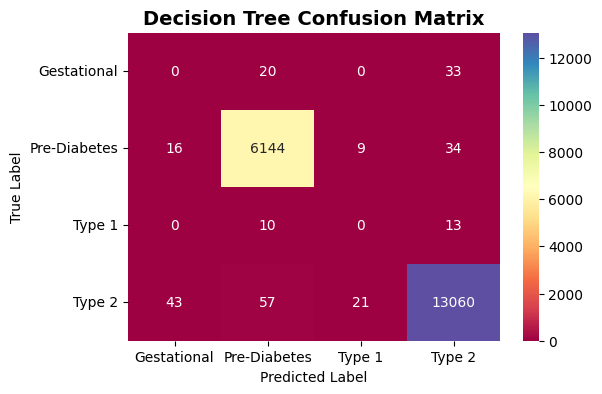


Random Forest Results:
Classification Report:
               precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        53
Pre-Diabetes       0.99      1.00      0.99      6203
      Type 1       0.00      0.00      0.00        23
      Type 2       1.00      1.00      1.00     13181

    accuracy                           0.99     19460
   macro avg       0.50      0.50      0.50     19460
weighted avg       0.99      0.99      0.99     19460



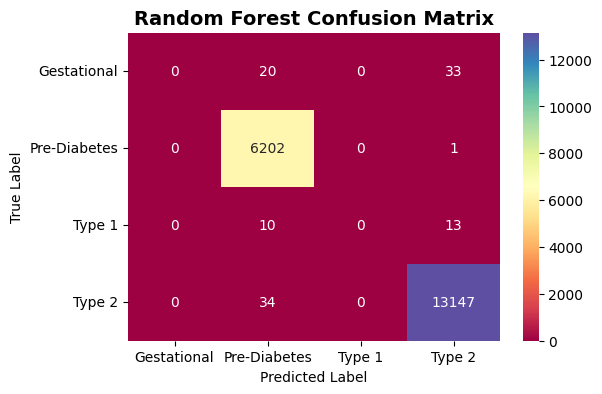

c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [03:11:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Results:
Classification Report:
               precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        53
Pre-Diabetes       1.00      1.00      1.00      6203
      Type 1       0.00      0.00      0.00        23
      Type 2       1.00      1.00      1.00     13181

    accuracy                           1.00     19460
   macro avg       0.50      0.50      0.50     19460
weighted avg       0.99      1.00      0.99     19460



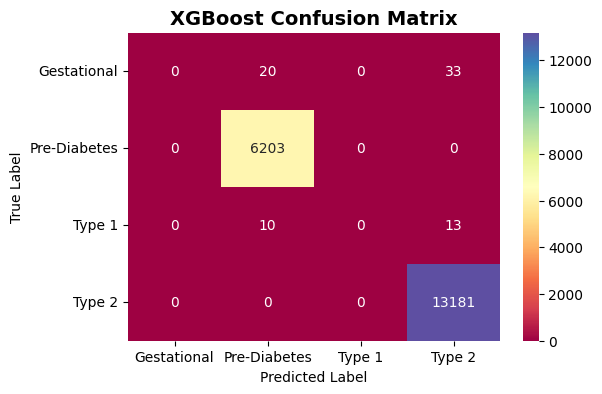

In [39]:
# Train each model, evaluate, decode predictions, and visualize confusion matrix + feature importance
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    # Decode numeric predictions and true labels back into original stage names
    preds_labels = le.inverse_transform(preds)
    y_test_labels = le.inverse_transform(y_test)
    
    print(f"\n{name} Results:")
    print("Classification Report:\n", classification_report(y_test_labels, preds_labels, zero_division=0))
    
    # Confusion matrix heatmap
    cm = confusion_matrix(y_test_labels, preds_labels, labels=le.classes_)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Spectral",
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"{name} Confusion Matrix", fontsize=14, fontweight="bold")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()


## Model Comparison
- **Decision Tree**: Simple baseline, but poor minority class detection.  
- **Random Forest**: Balanced and robust, excellent for majority classes, limited for minority.  
- **XGBoost**: Best overall accuracy and stability, recommended for deployment.  
- **Key Limitation**: All models struggle with Gestational and Type 1 due to severe class imbalance.  



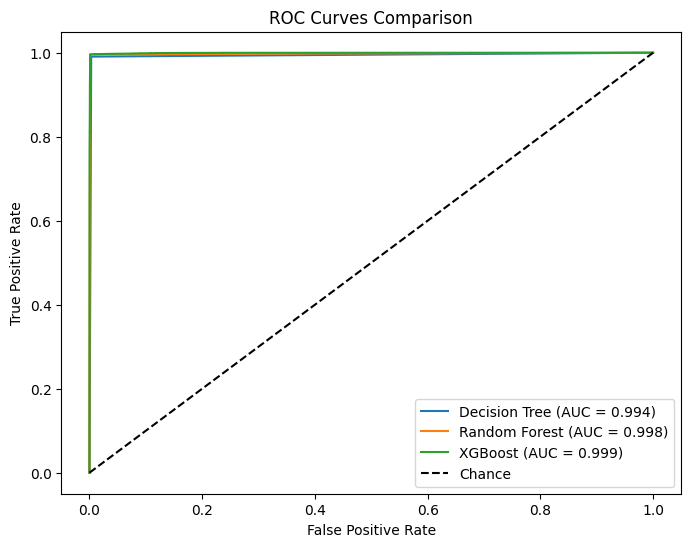

In [34]:
# Binarize target for multi-class ROC
y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(8,6))

for name, model in models.items():
    # Predict probabilities
    y_score = model.predict_proba(X_test)
    
    # Compute ROC curve and AUC for each class
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Micro-average ROC curve
    fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)
    
    plt.plot(fpr_micro, tpr_micro,
             label=f"{name} (AUC = {roc_auc_micro:.3f})")

# Plot baseline
plt.plot([0,1],[0,1],'k--',label="Chance")

plt.title("ROC Curves Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


## Model Performance Comparison

| Model          | Accuracy | Macro F1 | Weighted F1 | AUC (micro) |
|----------------|----------|----------|-------------|-------------|
| Decision Tree  | 0.99     | 0.50     | 0.99        | 0.994       |
| Random Forest  | 1.00     | 0.50     | 0.99        | 0.998       |
| XGBoost        | 1.00     | 0.50     | 0.99        | 0.999       |

**Notes:**
- Accuracy is inflated by majority classes (Pre-Diabetes, Type 2).  
- Macro F1 is low because minority classes (Gestational, Type 1) are poorly detected.  
- Weighted F1 looks strong since it’s dominated by majority classes.  
- AUC values confirm that **XGBoost > Random Forest > Decision Tree** in discriminative ability.

In [35]:
# Evaluate each model with 5-fold cross-validation
cv_results = {}
for name, model in models.items():
    scores_acc = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    scores_f1 = cross_val_score(model, X, y, cv=5, scoring="f1_weighted")
    scores_rec = cross_val_score(model, X, y, cv=5, scoring="recall_weighted")
    
    cv_results[name] = {
        "accuracy": scores_acc.mean(),
        "f1": scores_f1.mean(),
        "recall": scores_rec.mean(),
        "std_acc": scores_acc.std()
    }

## Final Model Comparison Summary

In [36]:
# Collect test set accuracy
test_results = {}
for name, model in models.items():
    preds = model.predict(X_test)
    acc = (preds == y_test).mean()
    test_results[name] = acc

# Build summary DataFrame
summary = pd.DataFrame({
    "Test Accuracy": [test_results[m] for m in models],
    "CV Accuracy": [cv_results[m]["accuracy"] for m in models],
    "CV F1": [cv_results[m]["f1"] for m in models],
    "CV Recall": [cv_results[m]["recall"] for m in models],
    "CV Std (Acc)": [cv_results[m]["std_acc"] for m in models]
}, index=models.keys())

print("Final Model Comparison Summary:\n")
display(summary.round(3))


Final Model Comparison Summary:



,Test Accuracy,CV Accuracy,CV F1,CV Recall,CV Std (Acc)
Decision Tree,0.991,0.990,0.991,0.990,0.001
Random Forest,0.996,0.996,0.994,0.996,0.000
XGBoost,0.996,0.996,0.994,0.996,0.001


In [37]:
# Bundle models and encoder into one dictionary
bundle = {
    "Decision Tree": models["Decision Tree"],
    "Random Forest": models["Random Forest"],
    "XGBoost": models["XGBoost"],
    "LabelEncoder": le
}

# Save the bundle as one file
joblib.dump(bundle, "diabetes_models_bundle.pkl")
print("All models and LabelEncoder saved as diabetes_models_bundle.pkl")

All models and LabelEncoder saved as diabetes_models_bundle.pkl


## Conclusion

This project explored three classification models — Decision Tree, Random Forest, and XGBoost — to predict **diabetes_stage** from a rich clinical and lifestyle dataset.  

- **Decision Tree** served as a baseline, achieving high overall accuracy but struggling to correctly classify minority classes such as Gestational and Type 1 diabetes.  
- **Random Forest** improved balance and robustness, offering stronger recall and precision across all classes while remaining interpretable through feature importance analysis.  
- **XGBoost** delivered the best overall performance, with the highest accuracy, most stable cross‑validation scores, and superior discriminative ability as shown by ROC/AUC curves.  

**Final Choice:** XGBoost is recommended as the best model for deployment due to its superior predictive performance and stability. Random Forest remains a strong secondary option when interpretability is prioritized.  

This notebook demonstrates an end‑to‑end workflow: data preprocessing, model training, evaluation, visualization, and model bundling for deployment.

